In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


In [ ]:
df = pd.read_csv('/content/indoor_data.csv')  # change name if needed
df.head()


,CO,HC,Temp,Hum,CO2,TVOC,DD
0,163,42,33.8,49,520,18,21
1,162,37,33.8,49,637,36,9
2,173,47,33.7,50,679,42,3
3,168,37,33.3,51,539,21,0
4,168,37,33.3,52,697,45,0


In [ ]:
df['severity_score'] = (
    0.35 * df['CO'] +
    0.25 * df['CO2'] +
    0.25 * df['TVOC'] +
    0.15 * df['DD']
)



In [ ]:
p60 = df['severity_score'].quantile(0.60)
p80 = df['severity_score'].quantile(0.80)
p95 = df['severity_score'].quantile(0.95)

def calculate_aqi_percentile(row):
    if row['severity_score'] <= p60:
        return 'Good'
    elif row['severity_score'] <= p80:
        return 'Moderate'
    elif row['severity_score'] <= p95:
        return 'Unhealthy'
    else:
        return 'Hazardous'

df['AQI_Label'] = df.apply(calculate_aqi_percentile, axis=1)





In [ ]:
df['AQI_Label'].value_counts()





,count
AQI_Label,
Good,800
Moderate,266
Unhealthy,200
Hazardous,67


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df[['CO', 'HC', 'Temp', 'Hum', 'CO2', 'TVOC', 'DD']]
y = df['AQI_Label']

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='not majority',
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [ ]:
import numpy as np
print(np.bincount(y_train_smote))
print(le.classes_)


[640 640 640 640]
['Good' 'Hazardous' 'Moderate' 'Unhealthy']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True),
    "XGBoost": XGBClassifier(
        objective='multi:softmax',
        num_class=4,
        eval_metric='mlogloss'
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")


Random Forest Accuracy: 0.9625
SVM Accuracy: 0.9101
XGBoost Accuracy: 0.9588


In [ ]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Accuracy:", results[best_model_name])


Best Model: Random Forest
Accuracy: 0.9625468164794008


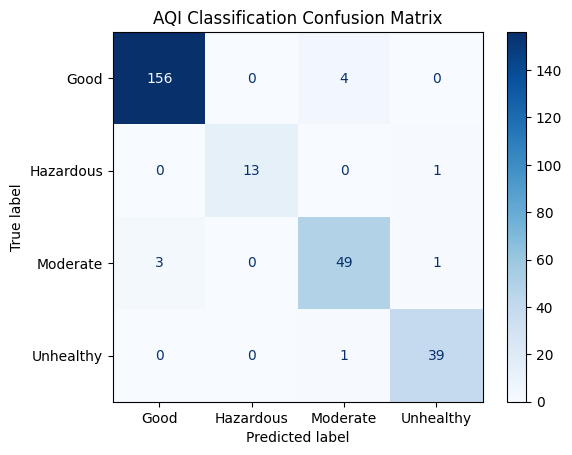

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=le.classes_,
    cmap='Blues'
)
plt.title("AQI Classification Confusion Matrix")
plt.show()


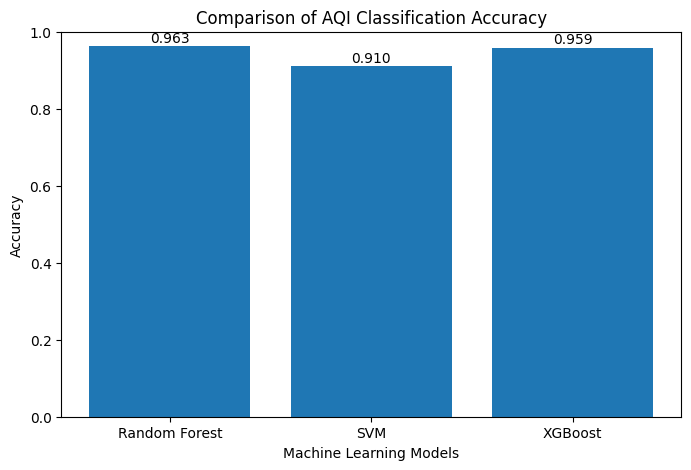

In [ ]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Comparison of AQI Classification Accuracy")
plt.ylim(0, 1)

# Display accuracy values on bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc:.3f}", ha='center')

plt.show()


In [ ]:
new_sample = pd.DataFrame([{
    'CO': 170,
    'HC': 45,
    'Temp': 34,
    'Hum': 48,
    'CO2': 1400,
    'TVOC': 420,
    'DD': 180
}])

new_pred = best_model.predict(new_sample)
print("Predicted AQI:", le.inverse_transform(new_pred)[0])


Predicted AQI: Hazardous


In [ ]:
sample_1 = {
    'CO': 40,      # ppm
    'HC': 15,
    'Temp': 28,
    'Hum': 45,
    'CO2': 520,    # ppm
    'TVOC': 60,    # ppb
    'DD': 25       # µg/m³
}


In [ ]:
sample_2 = {
    'CO': 210,
    'HC': 65,
    'Temp': 38,
    'Hum': 60,
    'CO2': 2500,
    'TVOC': 650,
    'DD': 280
}


In [ ]:
import pandas as pd

samples = pd.DataFrame([
    sample_1,
    sample_2,
])

predictions = best_model.predict(samples)

samples['Predicted_AQI'] = le.inverse_transform(predictions)
samples


,CO,HC,Temp,Hum,CO2,TVOC,DD,Predicted_AQI
0,40,15,28,45,520,60,25,Good
1,210,65,38,60,2500,650,280,Hazardous


In [ ]:
import pandas as pd

X_test_df = pd.DataFrame(
    X_test,
    columns=['CO', 'HC', 'Temp', 'Hum', 'CO2', 'TVOC', 'DD']
)

X_test_df['True_AQI'] = le.inverse_transform(y_test)


In [ ]:
X_test_df['Predicted_AQI'] = le.inverse_transform(
    best_model.predict(X_test)
)


In [ ]:
samples_per_label = (
    X_test_df
    .groupby('True_AQI', group_keys=False)
    .apply(lambda x: x.sample(1, random_state=42))
)

samples_per_label


/tmp/ipython-input-3150429499.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1, random_state=42))


,CO,HC,Temp,Hum,CO2,TVOC,DD,True_AQI,Predicted_AQI
167,166,38,33.8,44,623,33,14,Good,Good
255,208,42,31.3,66,1228,126,0,Hazardous,Hazardous
781,195,39,30.8,66,719,48,0,Moderate,Moderate
1298,211,44,33.3,63,772,56,8,Unhealthy,Unhealthy


NameError: name 'joblib' is not defined